Using torch vison dataset to train a nn model

In [30]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch

train_data = datasets.FashionMNIST(
    root="",
    train=True,
    transform=ToTensor(),
    download=True
)
test_data = datasets.FashionMNIST(
    root="",
    train=False,
    transform=ToTensor(),
    download=True
)

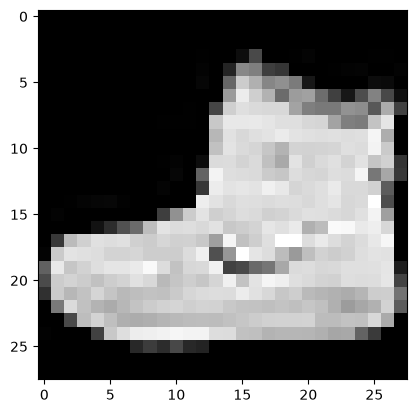

In [31]:
import matplotlib.pyplot as plt

img, label = train_data[0]
plt.imshow(img.squeeze(), cmap="gray")

In [32]:
BATCH_SIZE = 32
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

X,y = next(iter(train_dataloader))

In [33]:
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [34]:
X, y = next(iter(train_dataloader))

In [35]:
y[0]

tensor(1)

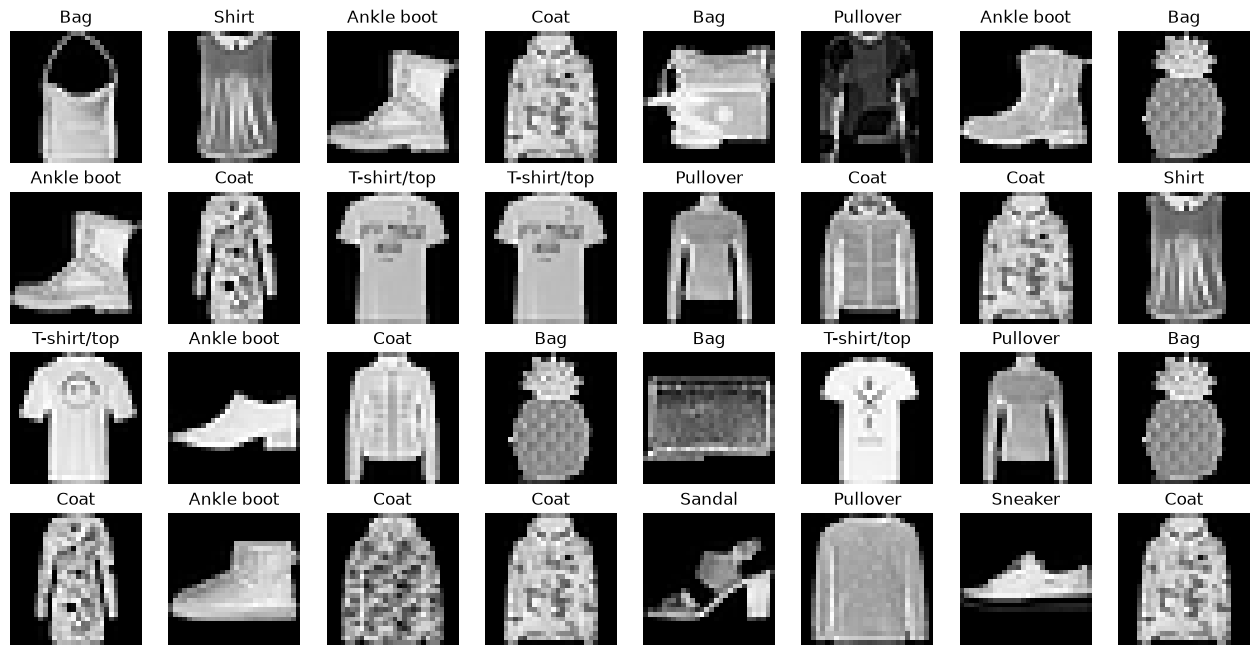

In [36]:
rows, cols = 4, 8
fig = plt.figure(figsize=(16,8))
for i in range(1,rows*cols+1):
    fig.add_subplot(rows,cols,i)
    idx = torch.randint(low=0,high=len(y),size=[1]).item()
    img, label = X[idx].squeeze(),y[idx].item()
    plt.imshow(img, cmap="gray")
    plt.axis(False)
    plt.title(classes[label])

In [37]:
from torch import nn
class Fashion(nn.Module):
    def __init__(self, in_:int, out:int, hidden:int):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=in_, out_features=hidden),
            nn.ReLU(),
            nn.Linear(in_features=hidden, out_features=out)
        )
        
    def forward(self, x):
        return self.layers(x)
    
    
model = Fashion(
    in_=(28*28),
    out=len(classes),
    hidden=10
)
model

Fashion(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [38]:
from sklearn.metrics import accuracy_score

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model.parameters(),
    lr=0.1
)


In [39]:
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

In [40]:
from tqdm.auto import tqdm
def train_model(
    model : torch.nn.Module,
    data_loader : torch.utils.data.DataLoader,
    loss_fn : torch.nn.Module,
    optimizer : torch.optim.Optimizer,
    acc_fn,
    device : torch.device = device
):
    model = model.to(device)
    model.train()
    train_acc, train_loss = 0, 0
    for batch, (X, y) in tqdm(enumerate(data_loader)):
        X = X.float().to(device)
        y = y.long().to(device)
        optimizer.zero_grad()
        y_logits = model(X)
        y_preds = y_logits.argmax(dim=1)
        loss = loss_fn(y_logits,y)
        train_loss += loss
        train_acc += acc_fn(y.cpu(),y_preds.cpu())
        loss.backward()
        optimizer.step()
    train_acc /= len(data_loader)
    train_loss /= len(data_loader)
    print(f"train loss : {train_loss:.4f} | train acc : {train_acc:.2f}")
    
    
def test_model(
    model : torch.nn.Module,
    loss_fn : torch.nn.Module,
    acc_fn,
    data_loader : torch.utils.data.DataLoader,
    device: torch.device = device,
):
    model = model.to(device)
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            X = X.float().to(device)
            y = y.long().to(device)
            y_logits = model(X)
            y_preds = y_logits.argmax(dim=1)
            loss = loss_fn(y_logits,y)
            test_loss += loss
            test_acc += acc_fn(y.cpu(), y_preds.cpu())
        test_acc /= len(data_loader)
        test_loss /= len(data_loader)
        print(f"test loss : {test_loss:.4f} | test acc : {test_acc:.2f}")

In [41]:
from timeit import default_timer as timer
st = timer()
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}\n---------")
    train_model(
        model=model,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        acc_fn=accuracy_score
    )
    test_model(
        model=model,
        loss_fn=loss_fn,
        acc_fn=accuracy_score,
        data_loader=test_dataloader
    )
end = timer()

print(f"time of execution : {end - st}")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
---------


0it [00:00, ?it/s]

train loss : 0.6359 | train acc : 0.77


  0%|          | 0/313 [00:00<?, ?it/s]

...

test loss : 0.4941 | test acc : 0.83
Epoch : 2
---------


0it [00:00, ?it/s]

train loss : 0.4606 | train acc : 0.84


  0%|          | 0/313 [00:00<?, ?it/s]

test loss : 0.4808 | test acc : 0.83
time of execution : 22.995268270999077


Lets build a convolutional layered model

In [42]:
class convolutionalFashion(nn.Module):
    def __init__(
        self,
        in_ : int,
        out : int,
        hidden : int
    ):
        super().__init__()
        torch.manual_seed(42)
        self.block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=in_,
                out_channels=hidden,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden,
                out_channels=hidden,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2),
            
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(hidden,hidden,3,1,1),
            nn.ReLU(),
            nn.Conv2d(hidden,hidden,3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden*7*7,out)
        )
        
        
    def forward (self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        
        return x
        

In [43]:
model_conv = convolutionalFashion(
    in_=1,
    out=len(classes),
    hidden=10
) 
model_conv

convolutionalFashion(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [44]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_conv.parameters(),
    lr=0.1
)

In [45]:
epochs = 3
st = timer()
for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}\n-------")
    
    train_model(
        model=model_conv,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        acc_fn=accuracy_score,
        device=device
    )
    
    test_model(
        model=model_conv,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        acc_fn=accuracy_score,
        device=device
    )
    
end = timer()

print(f"execution time : {end - st}")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
-------


0it [00:00, ?it/s]

train loss : 0.5793 | train acc : 0.79


  0%|          | 0/313 [00:00<?, ?it/s]

...

test loss : 0.3650 | test acc : 0.87
Epoch : 2
-------


0it [00:00, ?it/s]

train loss : 0.3163 | train acc : 0.89


  0%|          | 0/313 [00:00<?, ?it/s]

test loss : 0.3134 | test acc : 0.89
execution time : 26.964795206000417


In [58]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix


y_preds = []
y_test = test_data.targets
    
with torch.inference_mode():
    model_conv.to(device)
    model_conv.eval()
    for X,y in test_data:
        X = X.unsqueeze(dim=0).to(device)
        y_logits = model_conv(X)
        y_logits = y_logits.argmax(dim=1)
        y_preds.append(y_logits)
        
y_preds[:10], y_test.shape

([tensor([9], device='cuda:0'),
  tensor([2], device='cuda:0'),
  tensor([1], device='cuda:0'),
  tensor([1], device='cuda:0'),
  tensor([6], device='cuda:0'),
  tensor([1], device='cuda:0'),
  tensor([4], device='cuda:0'),
  tensor([6], device='cuda:0'),
  tensor([5], device='cuda:0'),
  tensor([7], device='cuda:0')],
 torch.Size([10000]))

(<Figure size 1000x700 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

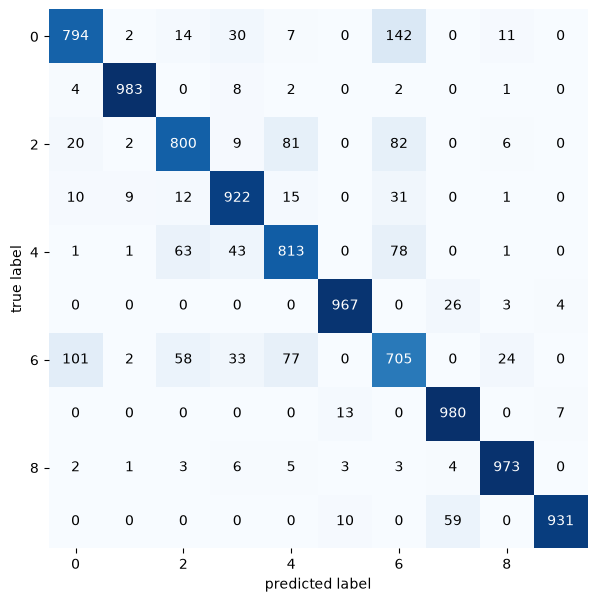

In [59]:
y_preds = torch.tensor(y_preds)
confmat = ConfusionMatrix(task='multiclass', num_classes=len(classes))
confmat_tensor = confmat(
    y_preds,y_test
)

plot_confusion_matrix(
    confmat_tensor.to("cpu").numpy(), classes, figsize=(10,7)
)